# Sinhala Fake News Detection — Preprocessing, Feature Extraction & CNN Model

**Phase 4 Pipeline:**
- Day 23 — Text cleaning (emojis, URLs, special characters)
- Day 24 — Tokenization + Sinhala stop word removal
- Day 25 — Unicode normalization
- Day 26 — FastText word embeddings
- Day 27 — Dataset split (70/15/15) + save preprocessed files
- Model — 1D-CNN text classifier with evaluation

## Setup — Imports & Load Data

In [3]:
import os, re, unicodedata, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from gensim.models import FastText

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Load raw data ──────────────────────────────────────────────────────────────
true_df  = pd.read_csv('TRUE.csv',  usecols=['source', 'content'])
false_df = pd.read_csv('FALSE.csv', usecols=['source', 'content'])

true_df['label']  = 1   # True News
false_df['label'] = 0   # False News

df = pd.concat([true_df, false_df], ignore_index=True)
df.dropna(subset=['content'], inplace=True)
df['content'] = df['content'].astype(str)

print(f"Total articles : {len(df)}")
print(f"True News      : {(df['label']==1).sum()}")
print(f"False News     : {(df['label']==0).sum()}")
df.head(3)

Total articles : 437
True News      : 327
False News     : 110


,source,content,label
0,lankaenews.lk,නුවරඑළිය දිස්ත්‍රික්කයේ ක්‍රියාත්මක නි⁣රෝධායන ...,1
1,ada.lk,ඉන්දියාවේ ඇක්සිස් බැංකුව විසින් 2019 වසරේදී එම...,1
2,asianmirror.lk,අද මේ කලබල වී සිටින පිරිස රනිල් වික්‍රමසිංහ ආණ...,1


## Day 23 — Text Cleaning (Remove Emojis, URLs, Special Characters)

In [4]:
def remove_urls(text):
    """Remove http/https URLs and www links."""
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def remove_emojis(text):
    """Remove emoji characters using Unicode ranges."""
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"   # emoticons
        "\U0001F300-\U0001F5FF"   # symbols & pictographs
        "\U0001F680-\U0001F6FF"   # transport & map
        "\U0001F1E0-\U0001F1FF"   # flags
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub('', text)

def remove_special_chars(text):
    """
    Keep Sinhala Unicode (U+0D80–U+0DFF), ASCII letters/digits,
    and basic Sinhala punctuation. Strip everything else.
    """
    # keep Sinhala script, ASCII alphanumeric, whitespace
    cleaned = re.sub(r'[^\u0D80-\u0DFF\u200C\u200D\s\w]', ' ', text)
    # collapse multiple whitespace
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

def clean_text(text):
    text = remove_urls(text)
    text = remove_emojis(text)
    text = remove_special_chars(text)
    return text

df['cleaned'] = df['content'].apply(clean_text)

# Show before / after
sample = df[['content', 'cleaned']].iloc[0]
print("── BEFORE ──────────────────────────────────────")
print(sample['content'][:300])
print("\n── AFTER ───────────────────────────────────────")
print(sample['cleaned'][:300])

── BEFORE ──────────────────────────────────────
නුවරඑළිය දිස්ත්‍රික්කයේ ක්‍රියාත්මක නි⁣රෝධායන ඇඳිරි නීතිය හෙට (31) මධ්‍යම රාත්‍රී 12 දක්වා ක්‍රියාත්මක වෙනවා . එම කාලය තුළ අත්‍යවශ්‍ය සේවා පවත්වාගෙන යාම සඳහා හැර අනෙකුත් සියලුම ගමනාගමන කටයුතු තහනම් . අනෙකුත් දිස්ත්‍රික්කවලට මීට පෙර ප්‍රකාශ කළ පරිදි හෙට (31) දවස පුරා ඇඳිරි නීතිය පැනවෙන බව ජනාධිපති මා

── AFTER ───────────────────────────────────────
නුවරඑළිය දිස්ත්‍රික්කයේ ක්‍රියාත්මක නි රෝධායන ඇඳිරි නීතිය හෙට 31 මධ්‍යම රාත්‍රී 12 දක්වා ක්‍රියාත්මක වෙනවා එම කාලය තුළ අත්‍යවශ්‍ය සේවා පවත්වාගෙන යාම සඳහා හැර අනෙකුත් සියලුම ගමනාගමන කටයුතු තහනම් අනෙකුත් දිස්ත්‍රික්කවලට මීට පෙර ප්‍රකාශ කළ පරිදි හෙට 31 දවස පුරා ඇඳිරි නීතිය පැනවෙන බව ජනාධිපති මාධ්‍ය අංශ


## Day 24 — Tokenization + Sinhala Stop Word Removal

In [5]:
# ── Comprehensive Sinhala stop words ──────────────────────────────────────────
SINHALA_STOPWORDS = {
    # conjunctions / connectives
    'සහ', 'හා', 'හෝ', 'හෝ', 'නමුත්', 'එහෙත්', 'නිසා', 'බැවින්', 'නම්',
    # demonstratives / pronouns
    'මෙම', 'ඒ', 'එම', 'එය', 'මෙය', 'ඔහු', 'ඇය', 'ඔවුන්', 'ඔවුහු', 'ඔවුනොවුන්',
    'ඔහුගේ', 'ඇගේ', 'ඔවුන්ගේ', 'මෙහි', 'එහි', 'මෙතැන', 'එතැන',
    # particles / auxiliaries
    'ද', 'ද්', 'ම', 'ත්', 'වෙත', 'විසින්', 'සඳහා', 'අතර', 'පිළිබඳ', 'ලෙස',
    'ලෙසම', 'ලෙසින්', 'ලෙසින', 'කෙසේ', 'යනු', 'යන', 'බව', 'යයි', 'කිව',
    # verbs (common copulas / auxiliaries)
    'වේ', 'වෙයි', 'ඇත', 'නැත', 'ඇති', 'නැති', 'විය', 'වී', 'කර', 'කළ',
    'කරයි', 'කරනු', 'කරන', 'ලබා', 'ලැබී', 'ලැබෙන', 'දී', 'ගෙන', 'ගොස්',
    # prepositions / postpositions
    'තුළ', 'සිට', 'දක්වා', 'වෙත', 'පිට', 'අනුව', 'යටතේ', 'හරහා',
    # numbers / determiners
    'එකක්', 'දෙකක්', 'කිහිපයක්', 'සියලු', 'සෑම', 'ඇතැම්', 'බොහෝ',
    # interrogatives
    'කවුද', 'කුමක්ද', 'කොතෙකද', 'කෙසේද', 'ඇයි', 'කවදා',
    # miscellaneous high-frequency function words
    'මෙලෙස', 'ඒ', 'ඒ්', 'ද', 'වන', 'වූ', 'යැයි', 'ඉදිරිපත්', 'ප්‍රකාශ',
}

def tokenize(text):
    """Tokenize on whitespace, keep only Sinhala-script tokens (≥ 2 chars)."""
    tokens = text.split()
    return [t for t in tokens
            if re.fullmatch(r'[\u0D80-\u0DFF\u200C\u200D]+', t) and len(t) >= 2]

def remove_stopwords(tokens):
    return [t for t in tokens if t not in SINHALA_STOPWORDS]

def tokenize_and_filter(text):
    tokens = tokenize(text)
    return remove_stopwords(tokens)

df['tokens'] = df['cleaned'].apply(tokenize_and_filter)

# Show stats
lengths = df['tokens'].apply(len)
print(f"Avg tokens per article : {lengths.mean():.1f}")
print(f"Median tokens          : {lengths.median():.0f}")
print(f"Max tokens             : {lengths.max()}")
print(f"\nSample tokens (first article):\n{df['tokens'].iloc[0][:20]}")

Avg tokens per article : 136.0
Median tokens          : 78
Max tokens             : 1314

Sample tokens (first article):
['නුවරඑළිය', 'දිස්ත්\u200dරික්කයේ', 'ක්\u200dරියාත්මක', 'නි', 'රෝධායන', 'ඇඳිරි', 'නීතිය', 'හෙට', 'මධ්\u200dයම', 'රාත්\u200dරී', 'ක්\u200dරියාත්මක', 'වෙනවා', 'කාලය', 'අත්\u200dයවශ්\u200dය', 'සේවා', 'පවත්වාගෙන', 'යාම', 'හැර', 'අනෙකුත්', 'සියලුම']


## Day 25 — Unicode Normalization (NFC → Consistent Sinhala Representation)

In [6]:
def normalize_sinhala(tokens):
    """
    Apply NFC Unicode normalization to each token.
    NFC composes characters into their canonical precomposed form,
    ensuring different byte sequences representing the same glyph
    are treated as identical tokens.
    """
    return [unicodedata.normalize('NFC', t) for t in tokens]

# Also fix common Sinhala encoding artifacts:
# Zero-width non-joiner (U+200C) and non-joiner (U+200D) used in Sinhala
# are sometimes incorrectly placed; keep them only where meaningful.
def fix_zwj(token):
    """Remove leading/trailing ZWJ/ZWNJ artifacts."""
    return token.strip('\u200C\u200D')

def full_normalize(tokens):
    tokens = normalize_sinhala(tokens)
    tokens = [fix_zwj(t) for t in tokens]
    return [t for t in tokens if len(t) >= 2]

df['tokens_norm'] = df['tokens'].apply(full_normalize)

# Check: how many tokens changed after normalization?
changed = sum(
    1 for orig, norm in zip(df['tokens'], df['tokens_norm'])
    if orig != norm
)
print(f"Articles with tokens changed by normalization: {changed}")

# Vocab size before vs after normalization
flat_before = [t for toks in df['tokens']      for t in toks]
flat_after  = [t for toks in df['tokens_norm'] for t in toks]
print(f"Vocab size before normalization : {len(set(flat_before)):,}")
print(f"Vocab size after  normalization : {len(set(flat_after)):,}")
print(f"Total tokens                    : {len(flat_after):,}")

Articles with tokens changed by normalization: 22
Vocab size before normalization : 12,534
Vocab size after  normalization : 12,503
Total tokens                    : 59,453


## Day 26 — Train FastText Embeddings

In [7]:
EMBED_DIM  = 100   # embedding dimension
MIN_COUNT  = 1    # include all tokens (small dataset)
WINDOW     = 5
EPOCHS_FT  = 30

corpus = df['tokens_norm'].tolist()   # list of token lists

print("Training FastText on corpus…")
ft_model = FastText(
    sentences=corpus,
    vector_size=EMBED_DIM,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=4,
    epochs=EPOCHS_FT,
    sg=1,           # skip-gram
    seed=SEED,
)
ft_model.save('fasttext_sinhala.model')
print(f"FastText trained  — vocab size: {len(ft_model.wv):,}")
print(f"Embedding dim     : {EMBED_DIM}")

# Quick sanity check
sample_word = corpus[0][0] if corpus[0] else None
if sample_word:
    similar = ft_model.wv.most_similar(sample_word, topn=5)
    print(f"\nTop-5 words similar to '{sample_word}':")
    for w, s in similar:
        print(f"  {w:30s}  {s:.4f}")

Training FastText on corpus…
FastText trained  — vocab size: 12,503
Embedding dim     : 100

Top-5 words similar to 'නුවරඑළිය':
  නුවරඑිළිය                       0.9446
  නුවරඑළියට                       0.9216
  දිස්ති‍්‍රක්කයේ                 0.8587
  කතරගම                           0.8554
  දිවුලිපිටිය                     0.8487
FastText trained  — vocab size: 12,503
Embedding dim     : 100

Top-5 words similar to 'නුවරඑළිය':
  නුවරඑිළිය                       0.9446
  නුවරඑළියට                       0.9216
  දිස්ති‍්‍රක්කයේ                 0.8587
  කතරගම                           0.8554
  දිවුලිපිටිය                     0.8487


## Day 27 — Dataset Split (70 / 15 / 15) + Build Vocabulary + Save Preprocessed Files

In [8]:
MAX_SEQ_LEN = 150   # pad/truncate to this length

# ── Build token→index vocabulary ──────────────────────────────────────────────
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

all_tokens = [t for toks in df['tokens_norm'] for t in toks]
vocab_counts = Counter(all_tokens)
vocab = [PAD_TOKEN, UNK_TOKEN] + [w for w, _ in vocab_counts.most_common()]
word2idx = {w: i for i, w in enumerate(vocab)}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx[PAD_TOKEN]
UNK_IDX    = word2idx[UNK_TOKEN]
print(f"Vocabulary size : {VOCAB_SIZE:,}")

# ── Build embedding matrix from FastText ──────────────────────────────────────
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
for word, idx in word2idx.items():
    if word in ft_model.wv:
        embed_matrix[idx] = ft_model.wv[word]
    elif word not in (PAD_TOKEN, UNK_TOKEN):
        embed_matrix[idx] = ft_model.wv.get_vector(word, norm=False)

print(f"Embedding matrix : {embed_matrix.shape}")

# ── Encode tokens to padded integer sequences ─────────────────────────────────
def encode(tokens, max_len):
    ids = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

df['encoded'] = df['tokens_norm'].apply(lambda t: encode(t, MAX_SEQ_LEN))

# ── 70 / 15 / 15 split (stratified) ──────────────────────────────────────────
X = np.array(df['encoded'].tolist(), dtype=np.int64)
y = df['label'].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):>4}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val):>4}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test):>4}  ({len(X_test)/len(X)*100:.1f}%)")

# ── Save preprocessed artifacts ───────────────────────────────────────────────
np.save('X_train.npy', X_train); np.save('y_train.npy', y_train)
np.save('X_val.npy',   X_val);   np.save('y_val.npy',   y_val)
np.save('X_test.npy',  X_test);  np.save('y_test.npy',  y_test)
np.save('embed_matrix.npy', embed_matrix)
with open('word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)

print("\nPreprocessed files saved ✓")

Vocabulary size : 12,505
Embedding matrix : (12505, 100)

Split sizes:
  Train :  305  (69.8%)
  Val   :   66  (15.1%)
  Test  :   66  (15.1%)

Split sizes:
  Train :  305  (69.8%)
  Val   :   66  (15.1%)
  Test  :   66  (15.1%)

Preprocessed files saved ✓

Preprocessed files saved ✓


## CNN Model — Architecture, Training & Evaluation

In [9]:
# ── PyTorch Dataset + Balanced Sampling ───────────────────────────────────────
from torch.utils.data import WeightedRandomSampler

class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

BATCH_SIZE = 32
train_ds = NewsDataset(X_train, y_train)
val_ds   = NewsDataset(X_val, y_val)
test_ds  = NewsDataset(X_test, y_test)

# Balanced sampling for imbalanced classes
train_class_counts = np.bincount(y_train)
class_sample_weight = 1.0 / train_class_counts
sample_weights = np.array([class_sample_weight[c] for c in y_train], dtype=np.float32)
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ── 1D-CNN Architecture (regularized) ────────────────────────────────────────
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_matrix,
                 num_classes=2, num_filters=96,
                 kernel_sizes=(2, 3, 4), dropout=0.65,
                 emb_dropout=0.25, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embedding.weight = nn.Parameter(torch.tensor(embed_matrix, dtype=torch.float32))

        # Freeze embeddings to reduce overfitting on small dataset
        self.embedding.weight.requires_grad = False

        self.emb_dropout = nn.Dropout(emb_dropout)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x)               # (batch, seq, embed)
        emb = self.emb_dropout(emb)
        emb = emb.permute(0, 2, 1)            # (batch, embed, seq)

        pooled = []
        for conv in self.convs:
            c = F.relu(conv(emb))
            c = F.max_pool1d(c, c.shape[2]).squeeze(2)
            pooled.append(c)

        cat = torch.cat(pooled, dim=1)
        out = self.fc(self.dropout(cat))
        return out

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

model = TextCNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    embed_matrix=embed_matrix,
    num_classes=2,
    num_filters=96,
    kernel_sizes=(2, 3, 4),
    dropout=0.65,
    emb_dropout=0.25,
    pad_idx=PAD_IDX,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Device: cpu
Trainable parameters: 87,266
TextCNN(
  (embedding): Embedding(12505, 100, padding_idx=0)
  (emb_dropout): Dropout(p=0.25, inplace=False)
  (convs): ModuleList(
    (0): Conv1d(100, 96, kernel_size=(2,), stride=(1,))
    (1): Conv1d(100, 96, kernel_size=(3,), stride=(1,))
    (2): Conv1d(100, 96, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.65, inplace=False)
  (fc): Linear(in_features=288, out_features=2, bias=True)
)


In [10]:
# ── Optimized Training Loop (anti-overfitting) ───────────────────────────────
# Smaller LR + stronger regularization + label smoothing + early stopping
criterion = nn.CrossEntropyLoss(label_smoothing=0.08)
optimizer = torch.optim.AdamW(model.parameters(), lr=7e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=4, factor=0.5
)

EPOCHS = 40
PATIENCE = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

best_val_loss = float('inf')
best_state = None
best_epoch = 0
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct = 0.0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()

        # gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        t_loss += loss.item() * len(yb)
        t_correct += (out.argmax(1) == yb).sum().item()

    model.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            v_loss += loss.item() * len(yb)
            v_correct += (out.argmax(1) == yb).sum().item()

    t_loss /= len(X_train)
    v_loss /= len(X_val)
    t_acc = t_correct / len(X_train)
    v_acc = v_correct / len(X_val)

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['lr'].append(current_lr)

    scheduler.step(v_loss)

    if v_loss < best_val_loss - 1e-4:
        best_val_loss = v_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 5 == 0 or epoch == 1:
        gap = (t_acc - v_acc) * 100
        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"Train Loss: {t_loss:.4f} Acc: {t_acc*100:.1f}% | "
            f"Val Loss: {v_loss:.4f} Acc: {v_acc*100:.1f}% | "
            f"Gap: {gap:+.1f}% | LR: {current_lr:.6f}"
        )

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no val-loss improvement for {PATIENCE} epochs)")
        break

if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), 'text_cnn_best.pt')
print(f"\nBest val loss: {best_val_loss:.4f} at epoch {best_epoch} — model saved ✓")

Epoch   1/40 | Train Loss: 0.7402 Acc: 53.1% | Val Loss: 0.8513 Acc: 24.2% | Gap: +28.9% | LR: 0.000700
Epoch   5/40 | Train Loss: 0.6441 Acc: 62.0% | Val Loss: 0.5948 Acc: 77.3% | Gap: -15.3% | LR: 0.000700
Epoch   5/40 | Train Loss: 0.6441 Acc: 62.0% | Val Loss: 0.5948 Acc: 77.3% | Gap: -15.3% | LR: 0.000700
Epoch  10/40 | Train Loss: 0.5769 Acc: 73.1% | Val Loss: 0.5966 Acc: 71.2% | Gap: +1.9% | LR: 0.000700
Epoch  10/40 | Train Loss: 0.5769 Acc: 73.1% | Val Loss: 0.5966 Acc: 71.2% | Gap: +1.9% | LR: 0.000700
Epoch  15/40 | Train Loss: 0.5538 Acc: 73.4% | Val Loss: 0.5695 Acc: 77.3% | Gap: -3.8% | LR: 0.000350
Epoch  15/40 | Train Loss: 0.5538 Acc: 73.4% | Val Loss: 0.5695 Acc: 77.3% | Gap: -3.8% | LR: 0.000350
Epoch  20/40 | Train Loss: 0.5071 Acc: 78.4% | Val Loss: 0.5519 Acc: 77.3% | Gap: +1.1% | LR: 0.000175
Epoch  20/40 | Train Loss: 0.5071 Acc: 78.4% | Val Loss: 0.5519 Acc: 77.3% | Gap: +1.1% | LR: 0.000175
Epoch  25/40 | Train Loss: 0.5374 Acc: 74.8% | Val Loss: 0.5480 Acc: 7

## Training Curves — Loss & Accuracy

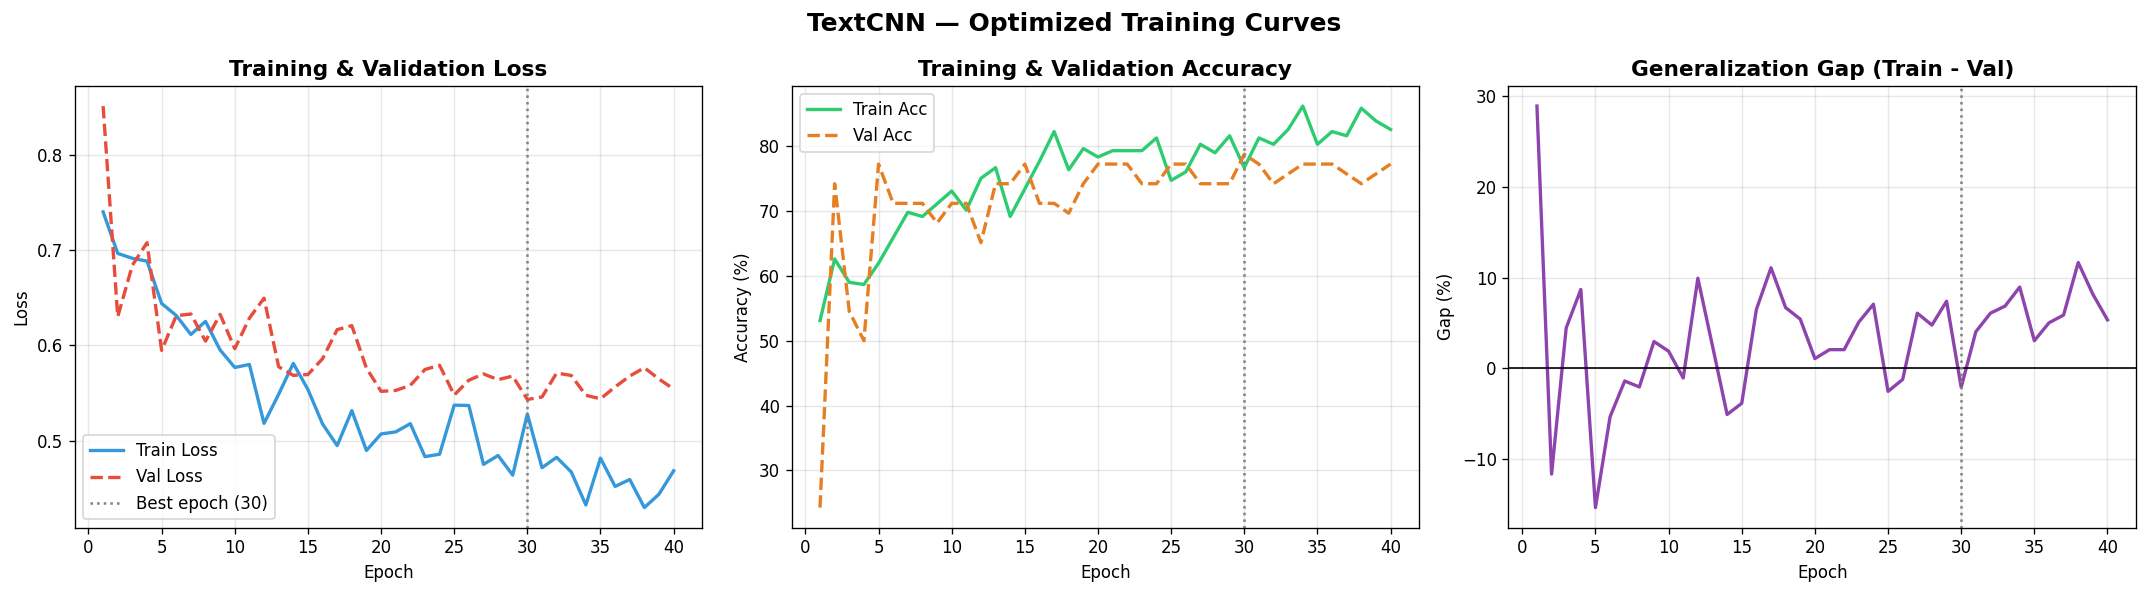

In [11]:
n_epochs_run = len(history['train_loss'])
epochs_range = range(1, n_epochs_run + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss',
             color='#3498db', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss',
             color='#e74c3c', linewidth=2, linestyle='--')
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='gray', linestyle=':', linewidth=1.5,
                label=f'Best epoch ({best_ep})')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
train_acc_pct = [a * 100 for a in history['train_acc']]
val_acc_pct = [a * 100 for a in history['val_acc']]
axes[1].plot(epochs_range, train_acc_pct,
             label='Train Acc', color='#2ecc71', linewidth=2)
axes[1].plot(epochs_range, val_acc_pct,
             label='Val Acc', color='#e67e22', linewidth=2, linestyle='--')
axes[1].axvline(best_ep, color='gray', linestyle=':', linewidth=1.5)
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Generalization gap
gap = np.array(train_acc_pct) - np.array(val_acc_pct)
axes[2].plot(epochs_range, gap, color='#8e44ad', linewidth=2)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].axvline(best_ep, color='gray', linestyle=':', linewidth=1.5)
axes[2].set_title('Generalization Gap (Train - Val)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap (%)')
axes[2].grid(alpha=0.3)

plt.suptitle('TextCNN — Optimized Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Test Set Evaluation — Confusion Matrix & Classification Report

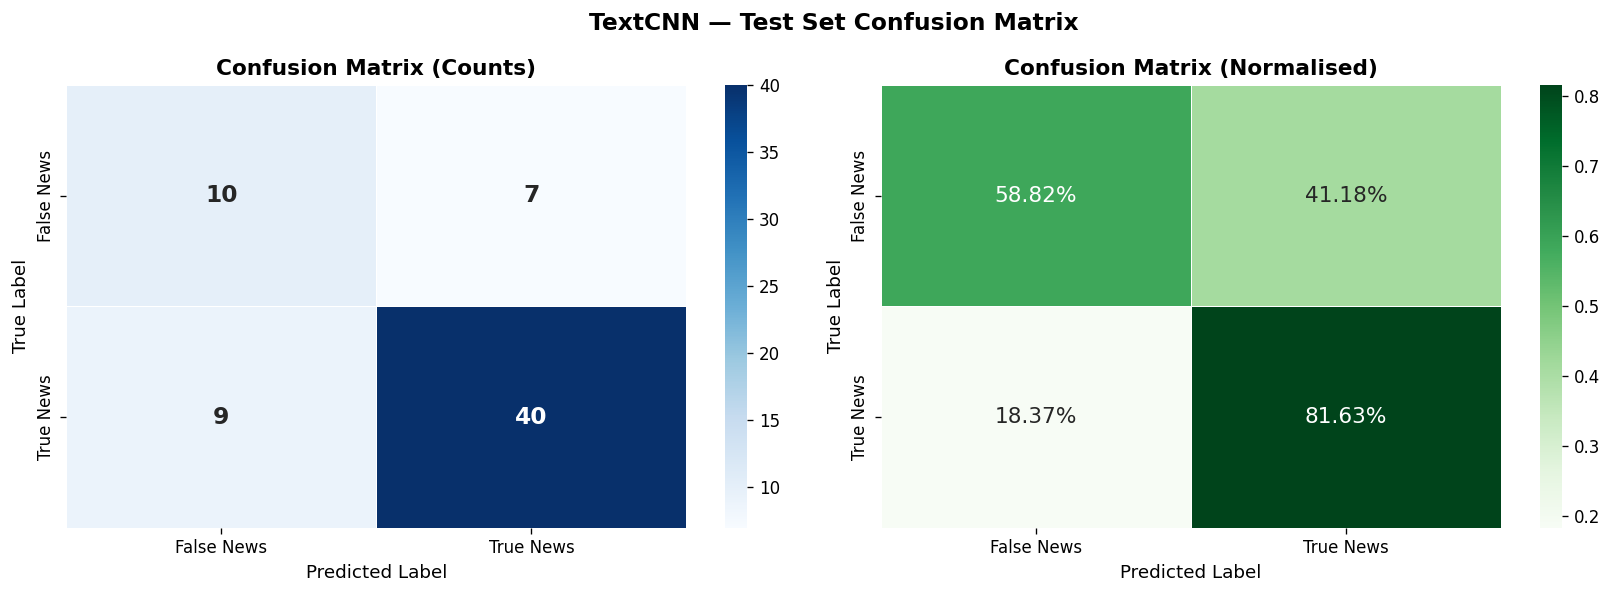

In [12]:
def predict(loader, model, device):
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out   = model(xb)
            probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_true.extend(yb.numpy())
    return np.array(all_true), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_prob = predict(test_loader, model, DEVICE)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
labels = ['False News', 'True News']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalised (row %)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 13})
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.suptitle('TextCNN — Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

CLASSIFICATION REPORT — Test Set
              precision    recall  f1-score   support

  False News     0.5263    0.5882    0.5556        17
   True News     0.8511    0.8163    0.8333        49

    accuracy                         0.7576        66
   macro avg     0.6887    0.7023    0.6944        66
weighted avg     0.7674    0.7576    0.7618        66

Overall Accuracy : 75.76%
Macro F1 Score   : 0.6944


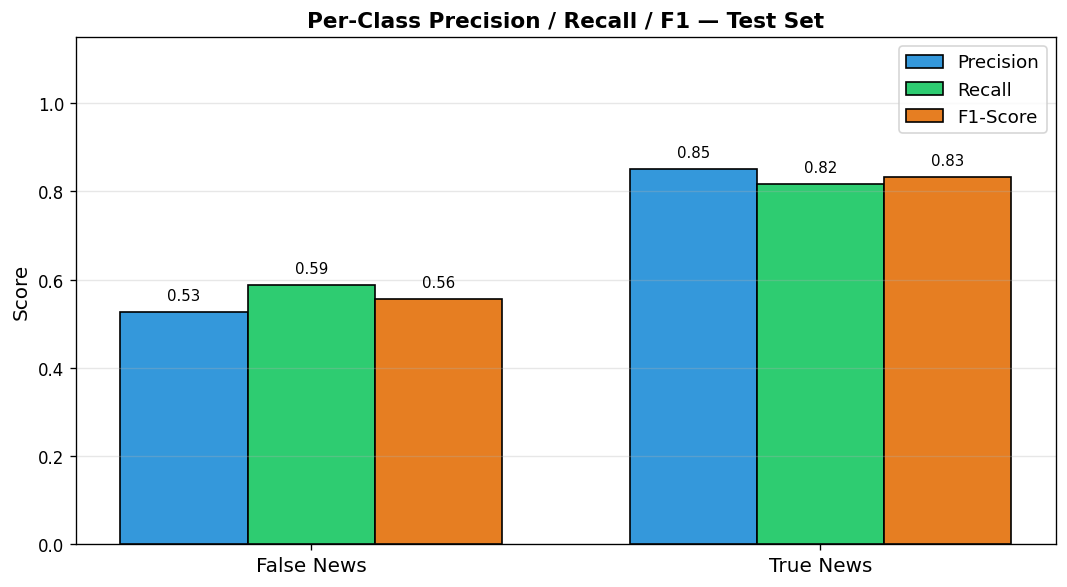

In [13]:
# ── Classification Report ─────────────────────────────────────────────────────
report = classification_report(y_true, y_pred,
                               target_names=['False News', 'True News'],
                               digits=4)
print("=" * 60)
print("CLASSIFICATION REPORT — Test Set")
print("=" * 60)
print(report)

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average='macro')
print(f"Overall Accuracy : {acc*100:.2f}%")
print(f"Macro F1 Score   : {f1:.4f}")

# ── Per-class metric bar chart ────────────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1s, _ = precision_recall_fscore_support(y_true, y_pred)

x = np.arange(2)
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, prec, width, label='Precision', color='#3498db',  edgecolor='black')
ax.bar(x,         rec,  width, label='Recall',    color='#2ecc71',  edgecolor='black')
ax.bar(x + width, f1s,  width, label='F1-Score',  color='#e67e22',  edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Precision / Recall / F1 — Test Set',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()